In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [28]:
dir1 = "MixedPlay/50reps_100eps_100epL_02jan2026_IQL_vs_IQL"
dir2 = "MixedPlay/50reps_100eps_100epL_03jan2026_IQL_vs_IQL"
df_1 = pd.read_csv(f"{dir1}/eval_returns.csv", index_col=0)
df_2 = pd.read_csv(f"{dir2}/eval_returns.csv", index_col=0)

In [29]:
# Helper function to parse return lists from CSV
def _to_list(l):
    l = l[1:-1].split(", ")
    return [float(elm) for elm in l]

def _mean(l):
    return np.mean(_to_list(l))

# Compute mean returns per repetition for agent 1
df_1["agent_1_mean"] = df_1["agent_1_returns"].apply(_mean)
df_2["agent_1_mean"] = df_2["agent_1_returns"].apply(_mean)

# Get the mean returns as arrays
agent_df1 = df_1["agent_1_mean"].values
agent_df2 = df_2["agent_1_mean"].values

print(f"Dataset 1: {len(agent_df1)} repetitions")
print(f"Dataset 2: {len(agent_df2)} repetitions")

Dataset 1: 50 repetitions
Dataset 2: 50 repetitions


In [30]:
def bootstrap_ci_test(sample1, sample2, n_bootstrap=1000, alpha=0.05):
    """
    Bootstrap test for difference in means using confidence intervals.
    H_0: no difference between means
    Reject H_0 if 0 is not in the bootstrap CI of the difference.
    
    :return: True if H_0 is rejected, False otherwise
    """
    observed_diff = np.mean(sample1) - np.mean(sample2)
    
    # Bootstrap the difference in means
    bootstrap_diffs = []
    for _ in range(n_bootstrap):
        boot_sample1 = np.random.choice(sample1, size=len(sample1), replace=True)
        boot_sample2 = np.random.choice(sample2, size=len(sample2), replace=True)
        bootstrap_diffs.append(np.mean(boot_sample1) - np.mean(boot_sample2))
    
    # Compute confidence interval (percentile method)
    ci_lower = np.percentile(bootstrap_diffs, 100 * alpha / 2)
    ci_upper = np.percentile(bootstrap_diffs, 100 * (1 - alpha / 2))
    
    # Reject H_0 if 0 is not in the CI
    return not (ci_lower <= 0 <= ci_upper)


def estimate_type1_error_welch(pooled_data, N, T=1000, alpha_target=0.05):
    """
    Empirical estimation of type-I error using Welch's t-test.
    """
    if len(pooled_data) < 2 * N:
        raise ValueError(f"Need at least {2*N} samples, but only have {len(pooled_data)}")
    
    rejections = 0
    
    for _ in range(T):
        if len(pooled_data) >= 2 * N:
            indices = np.random.choice(len(pooled_data), size=2*N, replace=False)
        else:
            indices = np.random.choice(len(pooled_data), size=2*N, replace=True)
        
        sampled = pooled_data[indices]
        split1 = sampled[:N]
        split2 = sampled[N:]
        
        # Welch's t-test (two-sided)
        _, p_value = stats.ttest_ind(split1, split2, equal_var=False)
        
        if p_value < alpha_target:
            rejections += 1
    
    return rejections / T


def estimate_type1_error_bootstrap(pooled_data, N, T=1000, alpha_target=0.05, n_bootstrap=1000):
    """
    Empirical estimation of type-I error using bootstrap CI test.
    """
    if len(pooled_data) < 2 * N:
        raise ValueError(f"Need at least {2*N} samples, but only have {len(pooled_data)}")
    
    rejections = 0
    
    for _ in range(T):
        if len(pooled_data) >= 2 * N:
            indices = np.random.choice(len(pooled_data), size=2*N, replace=False)
        else:
            indices = np.random.choice(len(pooled_data), size=2*N, replace=True)
        
        sampled = pooled_data[indices]
        split1 = sampled[:N]
        split2 = sampled[N:]
        
        # Bootstrap CI test
        if bootstrap_ci_test(split1, split2, n_bootstrap=n_bootstrap, alpha=alpha_target):
            rejections += 1
    
    return rejections / T


# Combine both datasets (same algorithm: IQL vs IQL)
# H_0 is true because all measurements come from the same distribution
pooled_data = np.concatenate([agent_df1, agent_df2])
print(f"Total pooled samples: {len(pooled_data)}")


Total pooled samples: 100


In [31]:
# Verify the pooling: show that 2×N samples are used for each N
print("=" * 70)
print("VERIFICATION: Data pooling for each N")
print("=" * 70)
print(f"{'N':>5} | {'Samples per split':>18} | {'Total samples (2×N)':>20} | {'From pool of':>12}")
print("-" * 70)

max_N = len(pooled_data) // 2
N_values = list(range(2, max_N + 1))

for N in N_values[:10]:  # Show first 10 for brevity
    print(f"{N:>5} | {N:>18} | {2*N:>20} | {len(pooled_data):>12}")
print("  ... |                ... |                  ... |          ...")
print(f"{N_values[-1]:>5} | {N_values[-1]:>18} | {2*N_values[-1]:>20} | {len(pooled_data):>12}")
print("-" * 70)
print(f"✓ As N increases, total samples used increases (2×N)")
print(f"✓ Maximum N = {max_N} (uses all {len(pooled_data)} pooled samples)")
print("=" * 70)


VERIFICATION: Data pooling for each N
    N |  Samples per split |  Total samples (2×N) | From pool of
----------------------------------------------------------------------
    2 |                  2 |                    4 |          100
    3 |                  3 |                    6 |          100
    4 |                  4 |                    8 |          100
    5 |                  5 |                   10 |          100
    6 |                  6 |                   12 |          100
    7 |                  7 |                   14 |          100
    8 |                  8 |                   16 |          100
    9 |                  9 |                   18 |          100
   10 |                 10 |                   20 |          100
   11 |                 11 |                   22 |          100
  ... |                ... |                  ... |          ...
   50 |                 50 |                  100 |          100
----------------------------------------------

In [43]:
# Run the empirical α estimation for each N using BOTH tests
T = 1000  # Number of test repetitions
alpha_target = 0.05
n_bootstrap = 1000  # Bootstrap samples for CI

# Limit N range for faster computation (bootstrap is slow)
N_values_limited = list(range(2, 51))  # N from 2 to 50

empirical_alphas_welch = []
empirical_alphas_bootstrap = []

print("Estimating empirical α for different sample sizes N...")
print("(This may take a while due to bootstrap computations)")
print("-" * 75)
print(f"{'N':>5} | {'2×N samples':>12} | {'Welch t-test':>14} | {'Bootstrap CI':>14}")
print("-" * 75)

for N in N_values_limited:
    # Welch's t-test
    emp_alpha_welch = estimate_type1_error_welch(pooled_data, N, T=T, alpha_target=alpha_target)
    empirical_alphas_welch.append(emp_alpha_welch)
    
    # Bootstrap CI test
    emp_alpha_boot = estimate_type1_error_bootstrap(pooled_data, N, T=T, alpha_target=alpha_target, n_bootstrap=n_bootstrap)
    empirical_alphas_bootstrap.append(emp_alpha_boot)
    
    print(f"{N:>5} | {2*N:>12} | {emp_alpha_welch:>14.4f} | {emp_alpha_boot:>14.4f}")

print("-" * 75)


Estimating empirical α for different sample sizes N...
(This may take a while due to bootstrap computations)
---------------------------------------------------------------------------
    N |  2×N samples |   Welch t-test |   Bootstrap CI
---------------------------------------------------------------------------


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


    2 |            4 |         0.0290 |         0.3430
    3 |            6 |         0.0460 |         0.1830
    4 |            8 |         0.0440 |         0.1610
    5 |           10 |         0.0400 |         0.1290
    6 |           12 |         0.0420 |         0.1050
    7 |           14 |         0.0500 |         0.1070
    8 |           16 |         0.0530 |         0.0980
    9 |           18 |         0.0510 |         0.0870
   10 |           20 |         0.0480 |         0.0860
   11 |           22 |         0.0430 |         0.0900
   12 |           24 |         0.0430 |         0.0730
   13 |           26 |         0.0570 |         0.0850
   14 |           28 |         0.0560 |         0.0640
   15 |           30 |         0.0540 |         0.0820
   16 |           32 |         0.0570 |         0.0500
   17 |           34 |         0.0480 |         0.0710
   18 |           36 |         0.0480 |         0.0730
   19 |           38 |         0.0420 |         0.0700
   20 |   

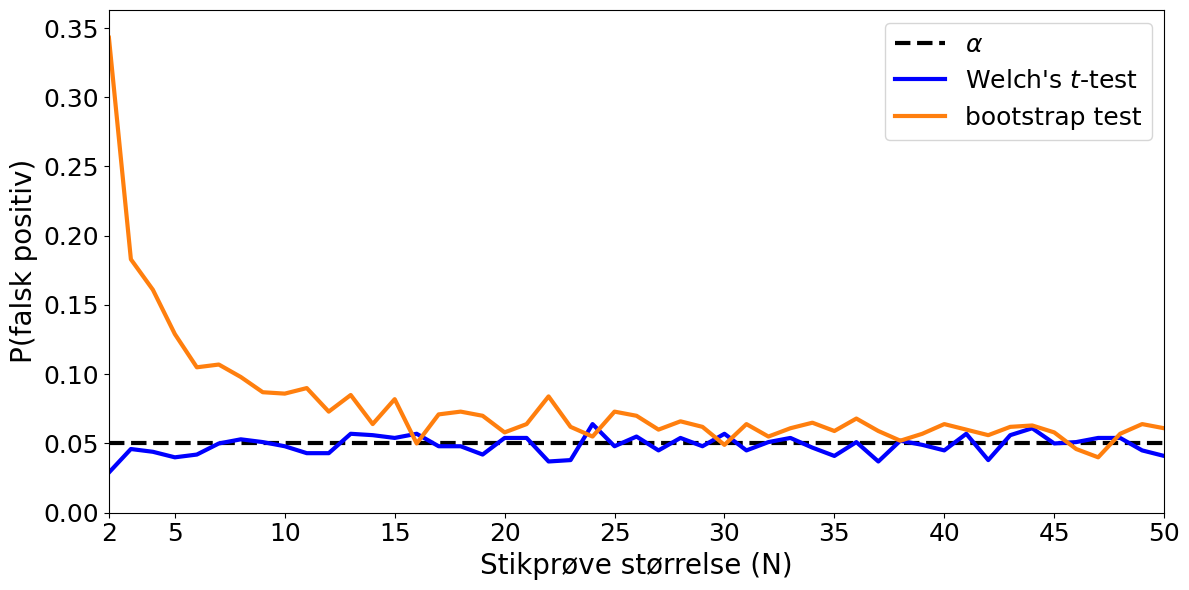

SUMMARY: Type-I Error (False Positive Rate) by Test and Sample Size

Target α = 0.05

Welch's t-test: Well-calibrated, stays close to α for all N
Bootstrap CI test: Inflated false positive rate for small N

At N=2:  Welch=0.029, Bootstrap=0.343
At N=10: Welch=0.048, Bootstrap=0.086
At N=21: Welch=0.041, Bootstrap=0.061
----------------------------------------------------------------------


In [50]:
# Plot empirical α vs N for BOTH tests (like Figure 6 in the paper)
fig, ax = plt.subplots(figsize=(12, 6))

# Target α line (black dashed)
ax.axhline(y=alpha_target, color='black', linestyle='--', linewidth=3, label=r'$\alpha$')

# Welch's t-test (blue)
ax.plot(N_values_limited, empirical_alphas_welch, 'b-', linewidth=3, label="Welch's $t$-test")

# Bootstrap test (orange/red)
ax.plot(N_values_limited, empirical_alphas_bootstrap, color='tab:orange', linewidth=3, label="bootstrap test")

ax.set_xlabel('Stikprøve størrelse (N)', fontsize=20)
ax.set_ylabel('P(falsk positiv)', fontsize=20)
#ax.set_title('Empirical Estimation of Type-I Error Rate\n(H₀: no difference, two-sided tests)', fontsize=18)
ax.legend(loc='upper right', fontsize=18)

# Increase tick label font size
ax.tick_params(axis='both', labelsize=18)

# Set axis limits similar to the paper figure
ax.set_ylim(0, max(0.35, max(empirical_alphas_bootstrap) + 0.02))
ax.set_xlim(min(N_values_limited), max(N_values_limited))

# Set ticks like in the paper
ax.set_xticks([2, 5, 10, 15, 20,25, 30,35,40,45,50])

plt.tight_layout()
plt.show()

# Summary
print("=" * 70)
print("SUMMARY: Type-I Error (False Positive Rate) by Test and Sample Size")
print("=" * 70)
print(f"\nTarget α = {alpha_target}")
print("\nWelch's t-test: Well-calibrated, stays close to α for all N")
print("Bootstrap CI test: Inflated false positive rate for small N")
print(f"\nAt N=2:  Welch={empirical_alphas_welch[0]:.3f}, Bootstrap={empirical_alphas_bootstrap[0]:.3f}")
print(f"At N=10: Welch={empirical_alphas_welch[8]:.3f}, Bootstrap={empirical_alphas_bootstrap[8]:.3f}")
print(f"At N=21: Welch={empirical_alphas_welch[-1]:.3f}, Bootstrap={empirical_alphas_bootstrap[-1]:.3f}")
print("-" * 70)

In [51]:
# Save the results to avoid re-running the expensive computation
import json

results = {
    'N_values': N_values_limited,
    'empirical_alphas_welch': empirical_alphas_welch,
    'empirical_alphas_bootstrap': empirical_alphas_bootstrap,
    'T': T,
    'alpha_target': alpha_target,
    'n_bootstrap': n_bootstrap
}

with open('empirical_alpha_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to 'empirical_alpha_results.json'")


Results saved to 'empirical_alpha_results.json'


In [ ]:
# Load saved results (run this instead of cells 5-6 to skip the computation)
import json

with open('empirical_alpha_results.json', 'r') as f:
    results = json.load(f)

N_values_limited = results['N_values']
empirical_alphas_welch = results['empirical_alphas_welch']
empirical_alphas_bootstrap = results['empirical_alphas_bootstrap']
T = results['T']
alpha_target = results['alpha_target']
n_bootstrap = results['n_bootstrap']

print(f"Loaded results: {len(N_values_limited)} N values, T={T}, α={alpha_target}")
